In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn import metrics
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
IMG_SHAPE = (224, 224)
BATCH_SIZE = 32

In [5]:
train_data = image_dataset_from_directory('D:\\Medical _Image_analyzer\\Bone_Fracture_Binary_Classification\\Bone_Fracture_Binary_Classification\\train',
                                    image_size= IMG_SHAPE,
                                    color_mode= 'rgb',
                                    batch_size= BATCH_SIZE,
                                    shuffle= True,
                                    seed = 2022
                                   )

Found 9246 files belonging to 2 classes.


In [6]:
test_data = image_dataset_from_directory('D:\\Medical _Image_analyzer\\Bone_Fracture_Binary_Classification\\Bone_Fracture_Binary_Classification\\test',
                                    image_size= IMG_SHAPE,
                                    color_mode= 'rgb',
                                    batch_size= BATCH_SIZE,
                                    shuffle= True,
                                    seed = 2022
                                   )

Found 506 files belonging to 2 classes.


In [ ]:
val_data = image_dataset_from_directory('D:\\Medical _Image_analyzer\\Bone_Fracture_Binary_Classification\\Bone_Fracture_Binary_Classification\\val',
                                    image_size= IMG_SHAPE,
                                    color_mode= 'rgb',
                                    batch_size= BATCH_SIZE,
                                    shuffle= True,
                                    seed = 2022
                                   )

Found 829 files belonging to 2 classes.


In [18]:
print("Total number of batches: ",len(train_data))


Total number of batches:  289


In [19]:
class_names = train_data.class_names
for idx, name in enumerate(class_names):
  print(f"{idx} = {name}", end=", ")

0 = fractured, 1 = not fractured, 

In [20]:
NO_CLASSES = len(class_names)
print("Number of classes = ", NO_CLASSES)

Number of classes =  2


In [22]:
train_data = train_data.apply(tf.data.experimental.ignore_errors())

train_data = train_data.ignore_errors()

labels = np.concatenate([y for x,y in train_data], axis=0)


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [23]:
values = pd.Series(labels).value_counts().sort_index()
values

0    4511
1    4543
Name: count, dtype: int64

AttributeError: '_IgnoreErrorsDataset' object has no attribute 'class_names'

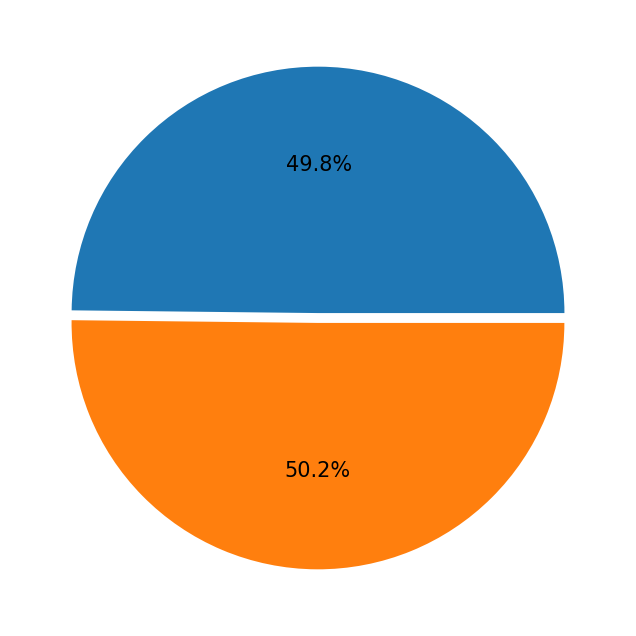

In [24]:
plt.figure(figsize=(12,8))
plt.pie(values,autopct='%1.1f%%', explode = [0.02] * len(values), textprops = {"fontsize":15})
plt.legend(labels=train_data.class_names)
plt.show()

In [25]:
data_iterator = train_data.as_numpy_iterator()
batch = data_iterator.next()
batch[0].shape

(32, 224, 224, 3)

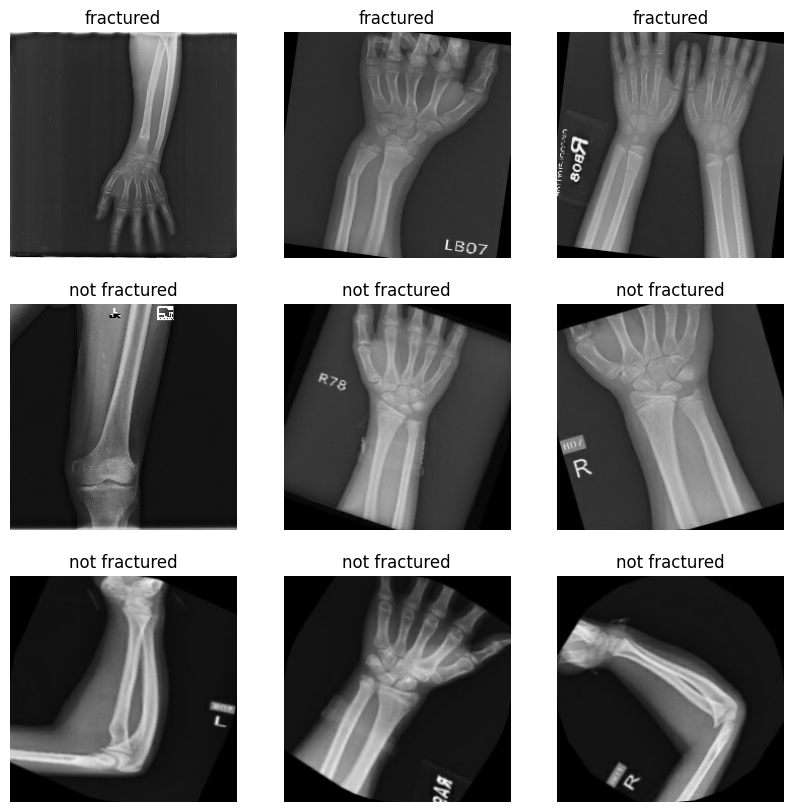

In [26]:
plt.figure(figsize=(10, 10))
for images, label in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[label[i]])
        plt.axis("off")

In [28]:
from config import MRI_MODEL_PATH
import tensorflow as tf
import pathlib as Path
def _load_model():
    """Lazy-load the MRI model once and cache it."""
    global _mri_model
    if _mri_model is None:
        from tensorflow.keras.models import load_model
        if not Path(MRI_MODEL_PATH).exists():
            raise FileNotFoundError(
                f"Saved model not found at '{MRI_MODEL_PATH}'. "
                "Please train the model first: python training/train_mri.py"
            )
        print(f"[MRI] Loading model from {MRI_MODEL_PATH} ...")
        _mri_model = load_model(MRI_MODEL_PATH, safe_mode=False)
        print("[MRI] Model loaded.")
    return _mri_model
model = _load_model()
model.summary()

NameError: name '_mri_model' is not defined